# NOTEBOOK 04: EXPLORACIÓN VISUAL Y VALIDACIÓN DE SEGMENTACIÓN HSV
---

Objetivo: Validar que la segmentación HSV funciona correctamente comparándola contra las máscaras ground truth de RivAIrSet.

---

# 1. Importaciones y configuración


In [1]:
import os
import time
os.chdir(r'D:\proyecto_eutrofizacion')

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Importa funciones de segmentación
import sys
sys.path.append('src')
from water_segmentation import *

# 2. Cargar índices de datasets

In [2]:
df_river = pd.read_csv('data/metadata/river_water_index.csv')

print(f"Total de imágenes RivAIrSet: {len(df_river)}")
print(f"Imágenes con máscara JSON: {df_river['segmentation_mask_path'].notna().sum()}")

# Filtra solo imágenes que tengan máscaras
df_river_con_mask = df_river[df_river['segmentation_mask_path'].notna()].copy()
print(f"Usaremos {len(df_river_con_mask)} imágenes para validación")


Total de imágenes RivAIrSet: 7630
Imágenes con máscara JSON: 7630
Usaremos 7630 imágenes para validación


# 3. Selecciona una imagen para empezar

In [4]:
df_river_con_mask = df_river[
    df_river['segmentation_mask_path'].notna()
].copy()

print(
    f"Imágenes disponibles para validación: "
    f"{len(df_river_con_mask)}"
)


if len(df_river_con_mask) == 0:

    print(
        "\n❌ ERROR: No hay imágenes con máscaras JSON."
    )

    sys.exit()

idx = df_river_con_mask.index[20]

row = df_river_con_mask.loc[idx]

ruta_imagen = row['filepath']
ruta_json = row['segmentation_mask_path']

print("\n" + "=" * 70)
print("IMAGEN DE VALIDACIÓN")
print("=" * 70)

print(f"Índice: {idx}")
print(f"Año/grupo: {row['group']}")
print(f"Imagen: {ruta_imagen}")
print(f"Máscara: {ruta_json}")


img = cv2.imread(ruta_imagen)

if img is None:

    print(
        f"\n❌ ERROR: No se pudo cargar:\n"
        f"{ruta_imagen}"
    )

    sys.exit()


alto, ancho = img.shape[:2]

print(
    f"\nDimensiones: {ancho} x {alto}"
)

Imágenes disponibles para validación: 7630

IMAGEN DE VALIDACIÓN
Índice: 20
Año/grupo: 2019
Imagen: data/raw/external/river_water_dataset\2019\images\DJI_1019.JPG
Máscara: data/raw/external/river_water_dataset\2019\labels_segmentation\DJI_1019.json

Dimensiones: 5280 x 3956


In [5]:
mascara_gt = cargar_mascara_desde_labelimg(
    ruta_json,
    alto,
    ancho
)

print("✓ Ground truth cargado")


if mascara_gt.max() == 0:

    print(
        "\n⚠️ ADVERTENCIA: "
        "La máscara ground truth está vacía."
    )


# ================================================================
# SEGMENTACIÓN
# ================================================================

print("\n" + "=" * 70)
print("SEGMENTACIÓN")
print("=" * 70)

start = time.time()

mascara_pred = segmentar_agua(
    img,
    v_max=80,
    downscale=4
)

elapsed = time.time() - start


# ================================================================
# MÉTRICAS
# ================================================================

metricas = calcular_metricas(
    mascara_pred,
    mascara_gt
)

print(
    f"\nTiempo: {elapsed * 1000:.2f} ms"
)

print(
    f"IoU:       {metricas['iou']:.6f}"
)

print(
    f"Precision:  {metricas['precision']:.6f}"
)

print(
    f"Recall:     {metricas['recall']:.6f}"
)

print(
    f"F1:         {metricas['f1']:.6f}"
)

✓ Ground truth cargado

SEGMENTACIÓN

Tiempo: 20.59 ms
IoU:       0.633543
Precision:  0.638645
Recall:     0.987549
F1:         0.775668


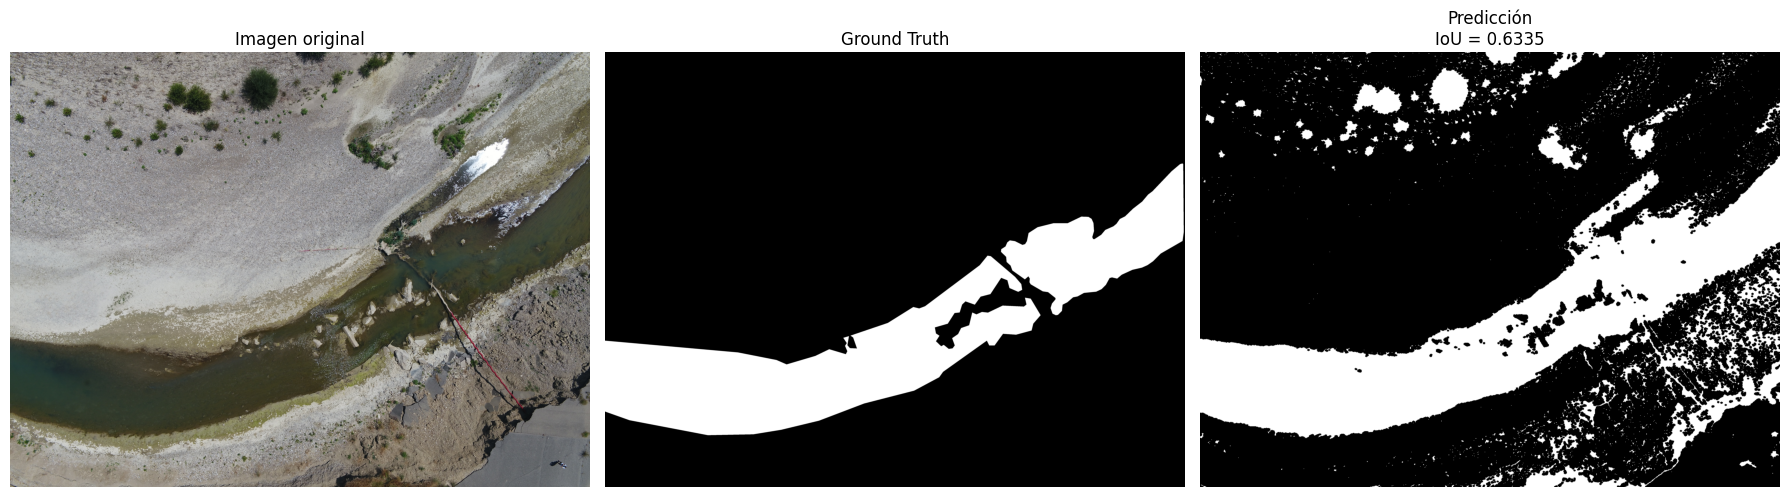

In [6]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

# Imagen original
axes[0].imshow(
    cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
)

axes[0].set_title(
    "Imagen original"
)

axes[0].axis('off')


# Ground truth
axes[1].imshow(
    mascara_gt,
    cmap='gray'
)

axes[1].set_title(
    "Ground Truth"
)

axes[1].axis('off')


# Predicción
axes[2].imshow(
    mascara_pred,
    cmap='gray'
)

axes[2].set_title(
    f"Predicción\n"
    f"IoU = {metricas['iou']:.4f}"
)

axes[2].axis('off')


plt.tight_layout()

os.makedirs(
    'outputs',
    exist_ok=True
)

plt.savefig(
    'outputs/segmentacion_ganadora.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# 4. Prueba segmentación HSV con parámetros por defecto

In [4]:
# Segmenta usando HSV simple
mascara_hsv = segmentar_agua_hsv(img)

# Calcula métricas
metricas = calcular_metricas(mascara_hsv, mascara_gt)

print(f"MÉTRICAS CON PARÁMETROS POR DEFECTO:")
print(f"  IoU:       {metricas['iou']:.4f}")
print(f"  Precision: {metricas['precision']:.4f}")
print(f"  Recall:    {metricas['recall']:.4f}")
print(f"  F1-score:  {metricas['f1']:.4f}")

⚠️  Advertencia: segmentar_agua_hsv() está deprecada.
   Usa segmentar_agua() en su lugar (más rápido y preciso).
MÉTRICAS CON PARÁMETROS POR DEFECTO:
  IoU:       0.3897
  Precision: 0.4851
  Recall:    0.6646
  F1-score:  0.5608


# 5. Visualiza las máscaras lado a lado

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Imagen original
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Imagen original')
axes[0, 0].axis('off')

# Máscara ground truth (JSON)
axes[0, 1].imshow(mascara_gt, cmap='gray')
axes[0, 1].set_title('Ground truth (JSON RivAIrSet)')
axes[0, 1].axis('off')

# Máscara HSV predicha
axes[1, 0].imshow(mascara_hsv, cmap='gray')
axes[1, 0].set_title(f'Predicción HSV (IoU: {metricas["iou"]:.3f})')
axes[1, 0].axis('off')

# Comparación: Verde = overlap correcto, Rojo = FP, Azul = FN
comparacion = np.zeros((alto, ancho, 3), dtype=np.uint8)

tp_mask = np.logical_and(mascara_hsv > 0, mascara_gt > 0)
fp_mask = np.logical_and(mascara_hsv > 0, mascara_gt == 0)
fn_mask = np.logical_and(mascara_hsv == 0, mascara_gt > 0)

comparacion[tp_mask] = [0, 255, 0]    # Verde = True Positive
comparacion[fp_mask] = [0, 0, 255]    # Rojo = False Positive
comparacion[fn_mask] = [255, 0, 0]    # Azul = False Negative

axes[1, 1].imshow(comparacion)
axes[1, 1].set_title(f'Análisis de errores\nVerde=TP, Rojo=FP, Azul=FN')
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('outputs/01_validacion_hsv_basico2.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"✓ Gráfico guardado en outputs/01_validacion_hsv_basico.png")


KeyboardInterrupt: 

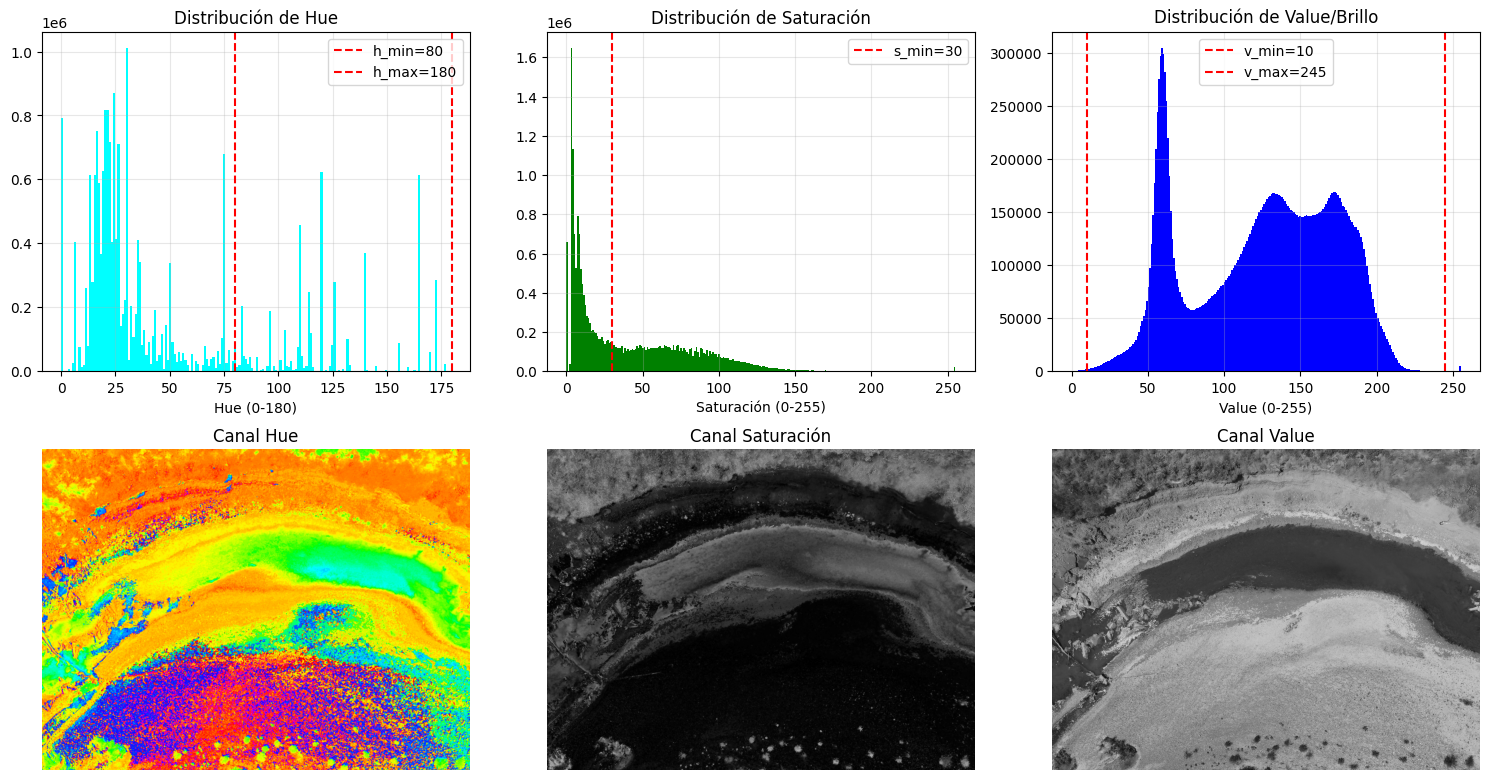

✓ Gráfico de diagnóstico guardado

ANÁLISIS DE PÍXELES AGUA EN GROUND TRUTH

Píxeles de agua según GT: 3680969
Rango Hue del agua:
  Min:  0
  Max:  178
  Mean: 49.5
Rango Saturación del agua:
  Min:  0
  Max:  255
  Mean: 67.9
Rango Value del agua:
  Min:  0
  Max:  255
  Mean: 66.0


In [23]:
# %% [markdown]
# ## 5.5 DIAGNÓSTICO: Mira el espacio HSV de la imagen

# Convierte a HSV y visualiza cada canal
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Canal Hue
axes[0, 0].hist(hsv[:,:,0].flatten(), bins=180, color='cyan')
axes[0, 0].axvline(80, color='red', linestyle='--', label='h_min=80')
axes[0, 0].axvline(180, color='red', linestyle='--', label='h_max=180')
axes[0, 0].set_title('Distribución de Hue')
axes[0, 0].set_xlabel('Hue (0-180)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Canal Saturation
axes[0, 1].hist(hsv[:,:,1].flatten(), bins=256, color='green')
axes[0, 1].axvline(30, color='red', linestyle='--', label='s_min=30')
axes[0, 1].set_title('Distribución de Saturación')
axes[0, 1].set_xlabel('Saturación (0-255)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Canal Value
axes[0, 2].hist(hsv[:,:,2].flatten(), bins=256, color='blue')
axes[0, 2].axvline(10, color='red', linestyle='--', label='v_min=10')
axes[0, 2].axvline(245, color='red', linestyle='--', label='v_max=245')
axes[0, 2].set_title('Distribución de Value/Brillo')
axes[0, 2].set_xlabel('Value (0-255)')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# Ahora visualiza cada canal por separado
axes[1, 0].imshow(hsv[:,:,0], cmap='hsv')
axes[1, 0].set_title('Canal Hue')
axes[1, 0].axis('off')

axes[1, 1].imshow(hsv[:,:,1], cmap='gray')
axes[1, 1].set_title('Canal Saturación')
axes[1, 1].axis('off')

axes[1, 2].imshow(hsv[:,:,2], cmap='gray')
axes[1, 2].set_title('Canal Value')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('outputs/03_diagnostico_hsv.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gráfico de diagnóstico guardado")

# Ahora analiza dónde están los píxeles del agua según la máscara GT
print("\n" + "="*70)
print("ANÁLISIS DE PÍXELES AGUA EN GROUND TRUTH")
print("="*70)

# Obtén solo los píxeles que GT dice que son agua
agua_pixels = hsv[mascara_gt > 0]

if len(agua_pixels) > 0:
    print(f"\nPíxeles de agua según GT: {len(agua_pixels)}")
    print(f"Rango Hue del agua:")
    print(f"  Min:  {agua_pixels[:,0].min()}")
    print(f"  Max:  {agua_pixels[:,0].max()}")
    print(f"  Mean: {agua_pixels[:,0].mean():.1f}")
    print(f"Rango Saturación del agua:")
    print(f"  Min:  {agua_pixels[:,1].min()}")
    print(f"  Max:  {agua_pixels[:,1].max()}")
    print(f"  Mean: {agua_pixels[:,1].mean():.1f}")
    print(f"Rango Value del agua:")
    print(f"  Min:  {agua_pixels[:,2].min()}")
    print(f"  Max:  {agua_pixels[:,2].max()}")
    print(f"  Mean: {agua_pixels[:,2].mean():.1f}")
else:
    print("❌ La máscara GT está vacía")

# 6. Prueba segmentación HSV robusta

In [24]:
mascara_hsv_robusto = segmentar_agua_hsv_robusto(img)
metricas_robusto = calcular_metricas(mascara_hsv_robusto, mascara_gt)

print(f"\nMÉTRICAS CON VERSIÓN ROBUSTA:")
print(f"  IoU:       {metricas_robusto['iou']:.4f}")
print(f"  Precision: {metricas_robusto['precision']:.4f}")
print(f"  Recall:    {metricas_robusto['recall']:.4f}")
print(f"  F1-score:  {metricas_robusto['f1']:.4f}")



MÉTRICAS CON VERSIÓN ROBUSTA:
  IoU:       0.0938
  Precision: 0.8154
  Recall:    0.0959
  F1-score:  0.1716


# 7. Ajuste interactivo de parámetros HSV

In [25]:
# Basado en el análisis:
# - Hue del agua: 0-178 (promedio 49.5) → verde-gris
# - Saturación: 0-255 (promedio 67.9)
# - Value: 0-255 (promedio 66.0)

nuevos_parametros = [
    # (nombre, h_min, h_max, s_min, s_max, v_min, v_max)
    ("Actual (Hue 50-180)", 50, 180, 10, 255, 0, 255),
    ("Ampliado a Hue 30-180", 30, 180, 10, 255, 0, 255),
    ("Muy ampliado: Hue 10-180", 10, 180, 10, 255, 0, 255),
    ("Ultra ampliado: Hue 0-180", 0, 180, 10, 255, 0, 255),
    ("Con restricción V (brillo)", 10, 180, 10, 255, 30, 240),
    ("Con restricción S (saturación)", 10, 180, 20, 255, 10, 240),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

mejores_resultados = []

for idx, (nombre, h_min, h_max, s_min, s_max, v_min, v_max) in enumerate(nuevos_parametros):
    mascara_test = segmentar_agua_hsv(
        img,
        h_min=h_min, h_max=h_max,
        s_min=s_min, s_max=s_max,
        v_min=v_min, v_max=v_max,
        kernel_size=5,
        iterations=1
    )
    
    metricas_test = calcular_metricas(mascara_test, mascara_gt)
    
    mejores_resultados.append({
        'nombre': nombre,
        'h_min': h_min,
        'h_max': h_max,
        's_min': s_min,
        's_max': s_max,
        'v_min': v_min,
        'v_max': v_max,
        'iou': metricas_test['iou'],
        'precision': metricas_test['precision'],
        'recall': metricas_test['recall'],
        'f1': metricas_test['f1']
    })
    
    # Visualiza
    axes[idx].imshow(mascara_test, cmap='gray')
    axes[idx].set_title(f"{nombre}\nIoU: {metricas_test['iou']:.3f} | "
                        f"Prec: {metricas_test['precision']:.3f} | "
                        f"Rec: {metricas_test['recall']:.3f}")
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('outputs/05_ajuste_hue.png', dpi=100, bbox_inches='tight')
plt.show()

# Tabla comparativa
df_mejores = pd.DataFrame(mejores_resultados)
print("\n" + "="*80)
print("PRUEBA DE PARÁMETROS AJUSTADOS")
print("="*80)
print(df_mejores[['nombre', 'iou', 'precision', 'recall', 'f1']].to_string(index=False))

print(f"\n✓ Mejor según IoU: {df_mejores.loc[df_mejores['iou'].idxmax(), 'nombre']}")
print(f"  IoU: {df_mejores['iou'].max():.4f}")

mejor_idx = df_mejores['iou'].idxmax()
mejor_row = df_mejores.iloc[mejor_idx]
print(f"\nParámetros recomendados:")
print(f"  h_min={mejor_row['h_min']}, h_max={mejor_row['h_max']}")
print(f"  s_min={mejor_row['s_min']}, s_max={mejor_row['s_max']}")
print(f"  v_min={mejor_row['v_min']}, v_max={mejor_row['v_max']}")

KeyboardInterrupt: 

# 8. Prueba en múltiples imágenes

In [6]:
print("\n" + "="*70)
print("VALIDACIÓN EN MÚLTIPLES IMÁGENES DE RivAIrSet")
print("="*70 + "\n")

resultados = []

# Toma hasta 10 imágenes de cada año para probar
for anio in sorted(df_river_con_mask['group'].unique()):
    df_anio = df_river_con_mask[df_river_con_mask['group'] == anio].head(5)
    
    print(f"\nAño {anio} - probando {len(df_anio)} imágenes...")
    
    iou_values = []
    
    for idx, row in df_anio.iterrows():
        ruta_img = row['filepath']
        ruta_msk = row['segmentation_mask_path']
        
        try:
            img_test = cv2.imread(ruta_img)
            msk_gt = cargar_mascara_desde_labelimg(ruta_msk, img_test.shape[0], img_test.shape[1])
            
            # Usa versión robusta
            msk_pred = segmentar_agua_hsv_robusto(img_test)
            iou = calcular_iou(msk_pred, msk_gt)
            
            iou_values.append(iou)
            resultados.append({
                'año': anio,
                'imagen': Path(ruta_img).name,
                'iou': iou
            })
        except Exception as e:
            print(f"  ⚠️  Error procesando {Path(ruta_img).name}: {e}")
    
    if iou_values:
        print(f"  IoU promedio: {np.mean(iou_values):.4f} ± {np.std(iou_values):.4f}")



VALIDACIÓN EN MÚLTIPLES IMÁGENES DE RivAIrSet


Año 2019 - probando 5 imágenes...
  IoU promedio: 0.0919 ± 0.0043

Año 2020 - probando 5 imágenes...
  IoU promedio: 0.0170 ± 0.0102

Año 2021 - probando 5 imágenes...
  IoU promedio: 0.3244 ± 0.2023

Año 2022 - probando 5 imágenes...
  IoU promedio: 0.2809 ± 0.0680

Año 2023 - probando 5 imágenes...
  IoU promedio: 0.0007 ± 0.0011

Año 2024 - probando 5 imágenes...
  IoU promedio: 0.0000 ± 0.0001


# 9. Resumen de resultados

df_resultados = pd.DataFrame(resultados)

print("\n" + "="*70)
print("RESUMEN DE VALIDACIÓN")
print("="*70)
print(f"\nTotal de imágenes probadas: {len(df_resultados)}")
print(f"IoU promedio: {df_resultados['iou'].mean():.4f}")
print(f"IoU mediana:  {df_resultados['iou'].median():.4f}")
print(f"IoU min:      {df_resultados['iou'].min():.4f}")
print(f"IoU max:      {df_resultados['iou'].max():.4f}")

# Distribuición por año
print(f"\nPor año:")
for anio in sorted(df_resultados['año'].unique()):
    iou_anio = df_resultados[df_resultados['año'] == anio]['iou']
    print(f"  {anio}: {iou_anio.mean():.4f} ± {iou_anio.std():.4f}")

# Visualiza histograma de IoU
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_resultados['iou'], bins=15, color='skyblue', edgecolor='black')
axes[0].axvline(df_resultados['iou'].mean(), color='red', linestyle='--', label=f"Media: {df_resultados['iou'].mean():.3f}")
axes[0].set_xlabel('IoU')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de IoU en todas las imágenes')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot por año
anos = sorted(df_resultados['año'].unique())
iou_by_year = [df_resultados[df_resultados['año'] == anio]['iou'].values for anio in anos]
axes[1].boxplot(iou_by_year, labels=anos)
axes[1].set_ylabel('IoU')
axes[1].set_xlabel('Año')
axes[1].set_title('IoU por año de RivAIrSet')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/02_resumen_iou.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n✓ Gráfico guardado en outputs/02_resumen_iou.png")


PRUEBA DE SEGMENTACIÓN MEJORADA


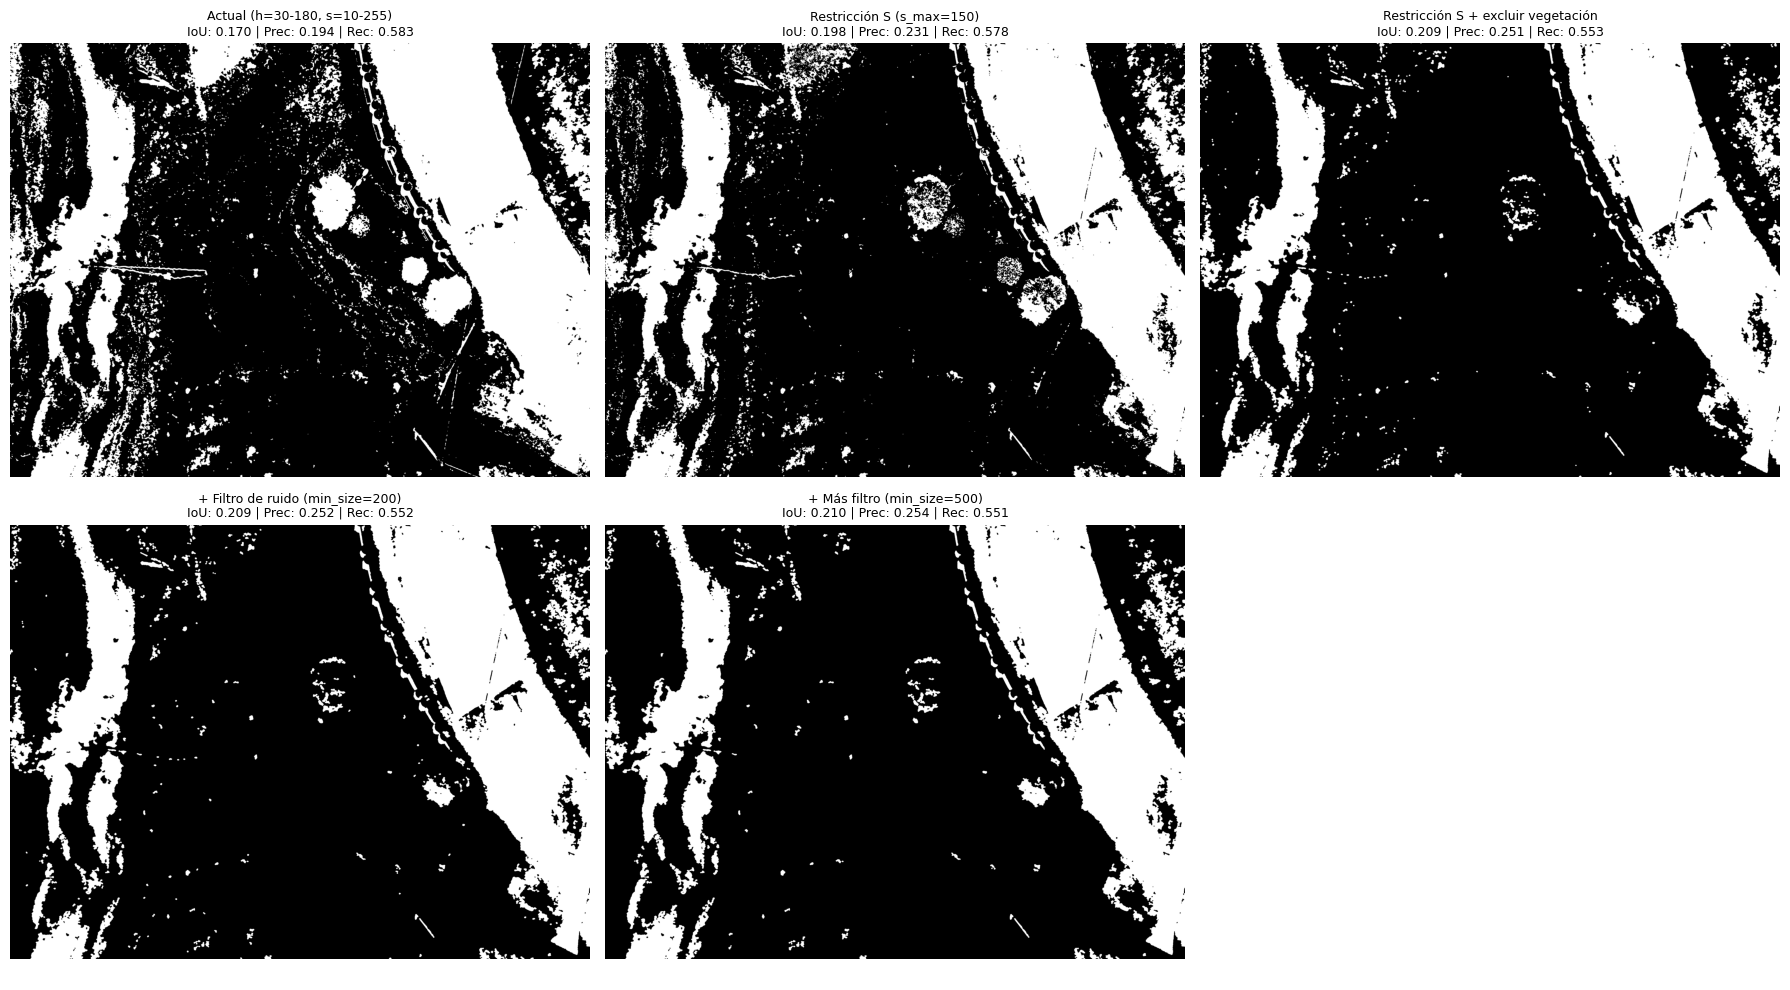


                            nombre      iou  precision   recall       f1
       Actual (h=30-180, s=10-255) 0.170455   0.194094 0.583257 0.291263
         Restricción S (s_max=150) 0.197519   0.230788 0.578099 0.329881
Restricción S + excluir vegetación 0.208876   0.251379 0.552645 0.345570
  + Filtro de ruido (min_size=200) 0.209354   0.252217 0.551945 0.346224
       + Más filtro (min_size=500) 0.210347   0.253908 0.550777 0.347581

✓ Mejor: + Más filtro (min_size=500)
  F1: 0.3476


In [4]:
print("="*70)
print("PRUEBA DE SEGMENTACIÓN MEJORADA")
print("="*70)

parametros_mejorados = [
    # (nombre, h_min, h_max, s_min, s_max, v_min, v_max, excluir_veg, min_size)
    ("Actual (h=30-180, s=10-255)", 30, 180, 10, 255, 0, 255, False, 0),
    ("Restricción S (s_max=150)", 30, 180, 15, 150, 15, 200, False, 0),
    ("Restricción S + excluir vegetación", 30, 180, 15, 150, 15, 200, True, 0),
    ("+ Filtro de ruido (min_size=200)", 30, 180, 15, 150, 15, 200, True, 200),
    ("+ Más filtro (min_size=500)", 30, 180, 15, 150, 15, 200, True, 500),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

mejoras = []

for idx, (nombre, h_min, h_max, s_min, s_max, v_min, v_max, exc_veg, min_sz) in enumerate(parametros_mejorados):
    
    if exc_veg or min_sz > 0:
        # Usa función mejorada
        mascara_mejorada = segmentar_agua_hsv_mejorado(
            img,
            h_min=h_min, h_max=h_max,
            s_min=s_min, s_max=s_max,
            v_min=v_min, v_max=v_max,
            excluir_vegetacion=exc_veg,
            min_size=min_sz
        )
    else:
        # Usa función básica
        mascara_mejorada = segmentar_agua_hsv(img, h_min, h_max, s_min, s_max, v_min, v_max)
    
    metricas_m = calcular_metricas(mascara_mejorada, mascara_gt)
    
    mejoras.append({
        'nombre': nombre,
        'iou': metricas_m['iou'],
        'precision': metricas_m['precision'],
        'recall': metricas_m['recall'],
        'f1': metricas_m['f1']
    })
    
    axes[idx].imshow(mascara_mejorada, cmap='gray')
    axes[idx].set_title(
        f"{nombre}\n"
        f"IoU: {metricas_m['iou']:.3f} | "
        f"Prec: {metricas_m['precision']:.3f} | "
        f"Rec: {metricas_m['recall']:.3f}",
        fontsize=9
    )
    axes[idx].axis('off')

axes[-1].axis('off')

plt.tight_layout()
plt.savefig('outputs/07_segmentacion_mejorada.png', dpi=100, bbox_inches='tight')
plt.show()

df_mejoras = pd.DataFrame(mejoras)
print("\n" + df_mejoras.to_string(index=False))

mejor_mejorada = df_mejoras.loc[df_mejoras['f1'].idxmax()]
print(f"\n✓ Mejor: {mejor_mejorada['nombre']}")
print(f"  F1: {mejor_mejorada['f1']:.4f}")

PRUEBA RÁPIDA DE MÉTODOS (con downscaling)


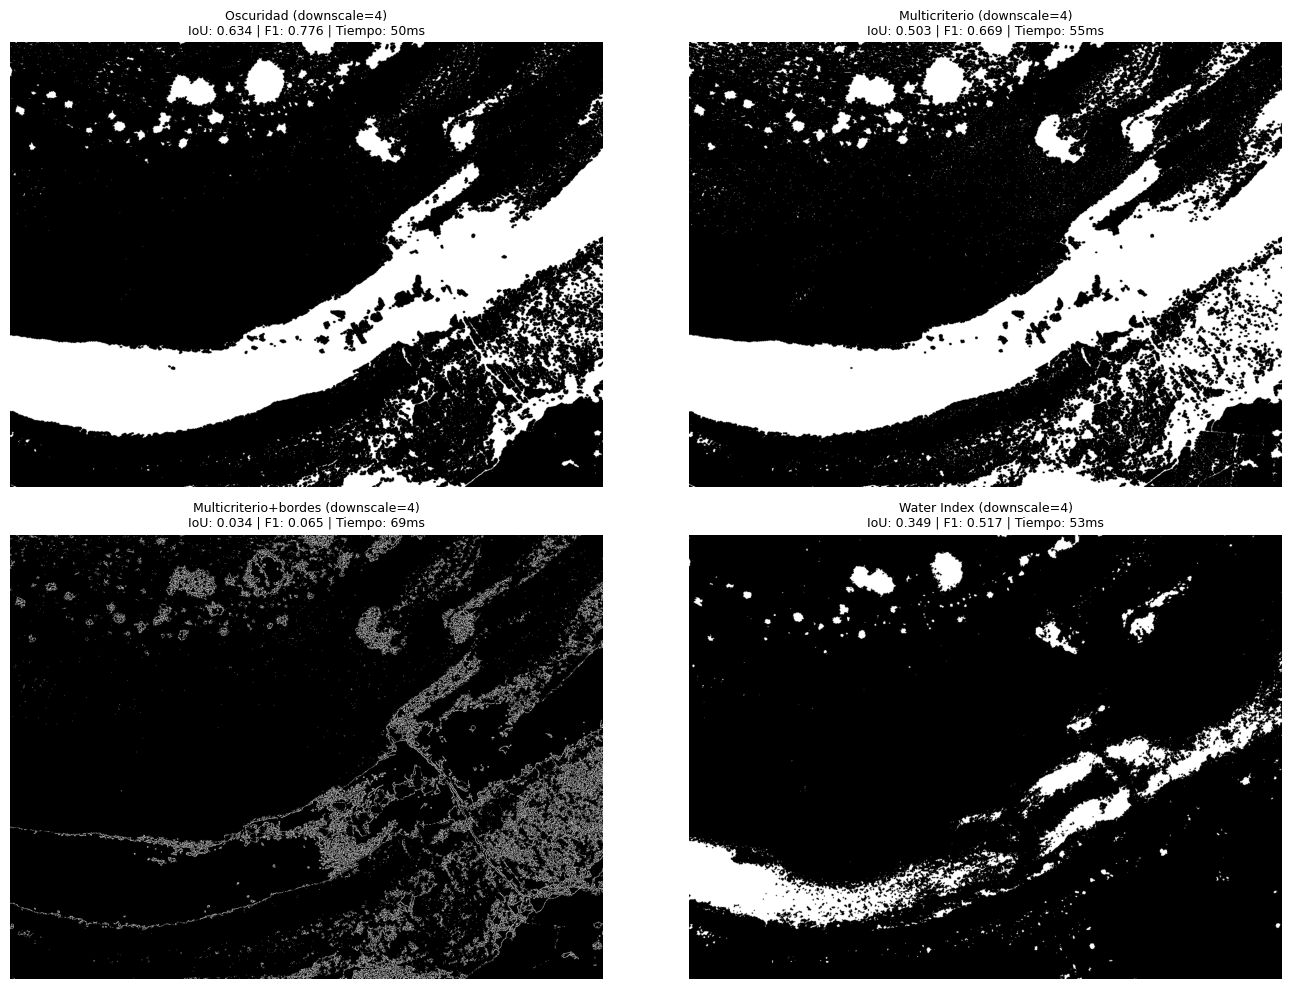


                            método  tiempo_ms      iou       f1
           Oscuridad (downscale=4)  50.271511 0.633543 0.775668
       Multicriterio (downscale=4)  54.719925 0.502964 0.669296
Multicriterio+bordes (downscale=4)  69.321156 0.033671 0.065149
         Water Index (downscale=4)  52.910566 0.348908 0.517319

✓ MEJOR (F1): Oscuridad (downscale=4)
  F1: 0.7757 en 50ms

⚡ MÁS RÁPIDO: Oscuridad (downscale=4)
  50ms (F1: 0.7757)


In [16]:
# src/water_segmentation_fast.py

"""
Versión OPTIMIZADA de segmentación de agua.
Prioriza VELOCIDAD sobre perfección.
"""

import cv2
import numpy as np


def segmentar_agua_por_oscuridad_rapido(imagen, 
                                        v_max=80, 
                                        min_area_pixels=1000,
                                        downscale=2):
    """
    VERSIÓN RÁPIDA: redimensiona, procesa, y restaura.
    
    downscale=2 significa procesar a 1/2 resolución (4x más rápido)
    downscale=4 significa procesar a 1/4 resolución (16x más rápido)
    """
    
    # PASO 1: Redimensiona (CRÍTICO para velocidad)
    altura_orig, ancho_orig = imagen.shape[:2]
    altura_new = altura_orig // downscale
    ancho_new = ancho_orig // downscale
    imagen_small = cv2.resize(imagen, (ancho_new, altura_new), interpolation=cv2.INTER_AREA)
    
    # PASO 2: HSV en imagen pequeña
    hsv = cv2.cvtColor(imagen_small, cv2.COLOR_BGR2HSV)
    
    # PASO 3: Threshold simple (muy rápido)
    _, mascara_oscuro = cv2.threshold(hsv[:,:,2], v_max, 255, cv2.THRESH_BINARY_INV)
    
    # PASO 4: Operaciones morfológicas mínimas
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mascara = cv2.morphologyEx(mascara_oscuro, cv2.MORPH_CLOSE, kernel, iterations=1)
    
    # PASO 5: Restaura a resolución original
    mascara_final = cv2.resize(mascara, (ancho_orig, altura_orig), interpolation=cv2.INTER_NEAREST)
    
    return mascara_final


def segmentar_agua_multicriterio_rapido(imagen,
                                        v_max=100,
                                        min_area=2000,
                                        use_edges=True,
                                        downscale=2):
    """
    VERSIÓN RÁPIDA del método multicriterio.
    downscale=2 o 4 para imágenes grandes.
    """
    
    # Redimensiona
    altura_orig, ancho_orig = imagen.shape[:2]
    altura_new = altura_orig // downscale
    ancho_new = ancho_orig // downscale
    imagen_small = cv2.resize(imagen, (ancho_new, altura_new), interpolation=cv2.INTER_AREA)
    
    hsv = cv2.cvtColor(imagen_small, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(imagen_small, cv2.COLOR_BGR2GRAY)
    
    # Criterio 1: Oscuridad
    _, mascara_oscuro = cv2.threshold(hsv[:,:,2], v_max, 255, cv2.THRESH_BINARY_INV)
    
    # Criterio 2: Morfología (cierre)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mascara = cv2.morphologyEx(mascara_oscuro, cv2.MORPH_CLOSE, kernel, iterations=1)
    
    # Criterio 3: Bordes (OPCIONAL - si es muy lento, desactiva)
    if use_edges:
        blurred = cv2.GaussianBlur(gray, (3, 3), 0.5)
        edges = cv2.Canny(blurred, 30, 100)  # Thresholds más bajos = más rápido
        mascara = cv2.bitwise_and(mascara, edges)
    
    # Restaura resolución original
    mascara_final = cv2.resize(mascara, (ancho_orig, altura_orig), interpolation=cv2.INTER_NEAREST)
    
    return mascara_final


def segmentar_agua_indice_simple_rapido(imagen, downscale=2):
    """
    Water Index rápido.
    """
    
    # Redimensiona
    altura_orig, ancho_orig = imagen.shape[:2]
    altura_new = altura_orig // downscale
    ancho_new = ancho_orig // downscale
    imagen_small = cv2.resize(imagen, (ancho_new, altura_new), interpolation=cv2.INTER_AREA)
    
    b, g, r = cv2.split(imagen_small)
    b = b.astype(np.float32)
    g = g.astype(np.float32)
    r = r.astype(np.float32)
    
    # Water Index
    numerador = 2*g - r - b
    denominador = 2*g + r + b
    denominador[denominador == 0] = 1
    wi = numerador / denominador
    
    # Threshold
    mascara = (wi > 0.1).astype(np.uint8) * 255
    
    # Limpia rápido
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel, iterations=1)
    
    # Restaura
    mascara_final = cv2.resize(mascara, (ancho_orig, altura_orig), interpolation=cv2.INTER_NEAREST)
    
    return mascara_final


# %% [markdown]
# ## COMPARACIÓN RÁPIDA DE MÉTODOS

import time
#from water_segmentation_fast import *

print("="*70)
print("PRUEBA RÁPIDA DE MÉTODOS (con downscaling)")
print("="*70)

metodos_rapidos = [
    ("Oscuridad (downscale=4)", lambda: segmentar_agua_por_oscuridad_rapido(img, downscale=4)),
    ("Multicriterio (downscale=4)", lambda: segmentar_agua_multicriterio_rapido(img, downscale=4, use_edges=False)),
    ("Multicriterio+bordes (downscale=4)", lambda: segmentar_agua_multicriterio_rapido(img, downscale=4, use_edges=True)),
    ("Water Index (downscale=4)", lambda: segmentar_agua_indice_simple_rapido(img, downscale=4)),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

resultados_rapido = []

for idx, (nombre, func_segmentar) in enumerate(metodos_rapidos):
    # Mide tiempo
    start = time.time()
    mascara = func_segmentar()
    elapsed = time.time() - start
    
    metricas_m = calcular_metricas(mascara, mascara_gt)
    
    resultados_rapido.append({
        'método': nombre,
        'tiempo_ms': elapsed * 1000,
        'iou': metricas_m['iou'],
        'f1': metricas_m['f1']
    })
    
    axes[idx].imshow(mascara, cmap='gray')
    axes[idx].set_title(
        f"{nombre}\n"
        f"IoU: {metricas_m['iou']:.3f} | F1: {metricas_m['f1']:.3f} | "
        f"Tiempo: {elapsed*1000:.0f}ms",
        fontsize=9
    )
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('outputs/11_comparacion_rapida.png', dpi=100, bbox_inches='tight')
plt.show()

df_rapido = pd.DataFrame(resultados_rapido)
print("\n" + df_rapido.to_string(index=False))

mejor = df_rapido.loc[df_rapido['f1'].idxmax()]
print(f"\n✓ MEJOR (F1): {mejor['método']}")
print(f"  F1: {mejor['f1']:.4f} en {mejor['tiempo_ms']:.0f}ms")

mas_rapido = df_rapido.loc[df_rapido['tiempo_ms'].idxmin()]
print(f"\n⚡ MÁS RÁPIDO: {mas_rapido['método']}")
print(f"  {mas_rapido['tiempo_ms']:.0f}ms (F1: {mas_rapido['f1']:.4f})")

In [4]:
import time

resultados_final = []
tiempos_final = []

for anio in sorted(df_river_con_mask['group'].unique()):

    df_anio = df_river_con_mask[
        df_river_con_mask['group'] == anio
    ].head(10)

    print(f"\nAño {anio}: ", end='')

    for idx, row in df_anio.iterrows():

        try:
            start = time.time()

            img_val = cv2.imread(row['filepath'])

            if img_val is None:
                raise ValueError(
                    f"No se pudo cargar: {row['filepath']}"
                )

            msk_gt = cargar_mascara_desde_labelimg(
                row['segmentation_mask_path'],
                img_val.shape[0],
                img_val.shape[1]
            )

            # EXACTAMENTE EL MÉTODO GANADOR
            msk_pred = segmentar_agua(
                img_val,
                v_max=80,
                downscale=4
            )

            elapsed = time.time() - start

            metricas = calcular_metricas(
                msk_pred,
                msk_gt
            )

            resultados_final.append({
                'año': anio,
                'iou': metricas['iou'],
                'precision': metricas['precision'],
                'recall': metricas['recall'],
                'f1': metricas['f1']
            })

            tiempos_final.append(elapsed)

            print('.', end='', flush=True)

        except Exception as e:

            print('X', end='', flush=True)

            print(
                f"\nERROR en {row['filepath']}: {e}"
            )

    print()


df_final = pd.DataFrame(resultados_final)

print("\n" + "="*70)
print("RESULTADO FINAL")
print("="*70)

if len(df_final) == 0:

    print("❌ No se pudo procesar ninguna imagen.")

else:

    print(
        f"Total imágenes validadas: "
        f"{len(df_final)}"
    )

    print(
        f"IoU promedio: "
        f"{df_final['iou'].mean():.4f}"
    )

    print(
        f"IoU mediana: "
        f"{df_final['iou'].median():.4f}"
    )

    print(
        f"IoU desviación estándar: "
        f"{df_final['iou'].std():.4f}"
    )

    print(
        f"\nF1 promedio: "
        f"{df_final['f1'].mean():.4f}"
    )

    print(
        f"Precision promedio: "
        f"{df_final['precision'].mean():.4f}"
    )

    print(
        f"Recall promedio: "
        f"{df_final['recall'].mean():.4f}"
    )

    print(
        f"\nTiempo promedio: "
        f"{np.mean(tiempos_final)*1000:.1f} ms"
    )

    print(
        f"Velocidad: "
        f"{1/np.mean(tiempos_final):.1f} imágenes/s"
    )

    print(
        f"\nIoU > 0.60: "
        f"{(df_final['iou'] > 0.60).sum()}/"
        f"{len(df_final)}"
    )

    print(
        f"IoU > 0.50: "
        f"{(df_final['iou'] > 0.50).sum()}/"
        f"{len(df_final)}"
    )


Año 2019: ..........

Año 2020: ..........

Año 2021: ..........

Año 2022: ..........

Año 2023: ..........

Año 2024: ..........

RESULTADO FINAL
Total imágenes validadas: 60
IoU promedio: 0.0820
IoU mediana: 0.0024
IoU desviación estándar: 0.1581

F1 promedio: 0.1205
Precision promedio: 0.0919
Recall promedio: 0.1897

Tiempo promedio: 366.5 ms
Velocidad: 2.7 imágenes/s

IoU > 0.60: 0/60
IoU > 0.50: 3/60
